# Day 4: Linear algebra 3: eigenvalues and eigenvectors

**Fri, Oct 9 · Prep · about 45 minutes**

In quantum computing, the possible results of a measurement are the eigenvalues of a matrix, and the states you can land in are its eigenvectors. That makes today one of the most important prep days.

**By the end of this notebook you can:**
- Explain an eigenvector as a direction a matrix only stretches
- Solve det(A − λI) = 0 for a 2×2 matrix
- Connect eigenvalues to measurement outcomes

> How to use this notebook: read each explanation, run the cell under it, then change the numbers and run it again.
> The exercises at the end have a "your turn" cell and a hidden worked solution. Try first, then check.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.figsize": (5, 5), "axes.grid": True, "grid.alpha": 0.3})

def tex(label):
    """Typeset a ket label like '|+>' as a proper |+⟩ in plots."""
    if label.startswith("|") and label.endswith(">"):
        return r"$|" + label[1:-1] + r"\rangle$"
    return label

## 1. The idea
Most vectors change direction when a matrix acts on them. **Eigenvectors** are the special ones that stay on their own line:

**A v = λ v**

The number λ is the **eigenvalue**: how much v is stretched (λ > 1), shrunk (0 < λ < 1), or flipped (λ < 0).

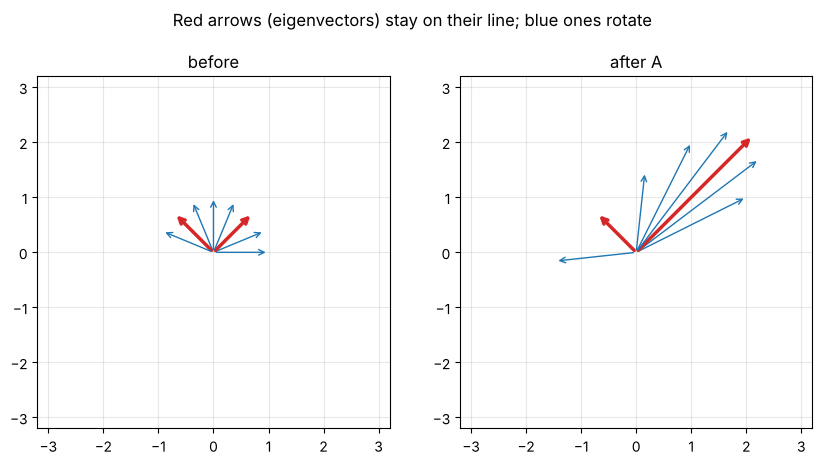

In [2]:
A = np.array([[2, 1],
              [1, 2]])
angles = np.linspace(0, np.pi, 8, endpoint=False)  # every 22.5 deg, includes 45 and 135
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, title, M in [(axes[0], "before", np.eye(2)), (axes[1], "after A", A)]:
    for a in angles:
        v = np.array([np.cos(a), np.sin(a)]); w = M @ v
        Av = A @ v
        is_eig = np.isclose(v[0] * Av[1] - v[1] * Av[0], 0)  # parallel test
        c = "C3" if is_eig else "C0"
        ax.annotate("", xy=w, xytext=(0, 0), arrowprops=dict(arrowstyle="->", color=c, lw=2.5 if is_eig else 1))
    ax.set_xlim(-3.2, 3.2); ax.set_ylim(-3.2, 3.2); ax.set_aspect("equal"); ax.set_title(title)
fig.suptitle("Red arrows (eigenvectors) stay on their line; blue ones rotate")
plt.show()

## 2. Finding them by hand
Rewrite A v = λ v as (A − λI) v = 0. A non-zero v exists only when **det(A − λI) = 0**. That's the characteristic equation.

For A = [[2, 1], [1, 2]]:
det [[2 − λ, 1], [1, 2 − λ]] = (2 − λ)² − 1 = 0 → 2 − λ = ±1 → **λ = 1 or λ = 3**.

- λ = 3: (A − 3I)v = 0 gives −v₀ + v₁ = 0, so **v = (1, 1)/√2**.
- λ = 1: (A − I)v = 0 gives v₀ + v₁ = 0, so **v = (1, −1)/√2**.

In [3]:
vals, vecs = np.linalg.eig(A)
print("eigenvalues:", vals)
print("eigenvectors (columns):\n", vecs)
for k in range(2):
    v = vecs[:, k]
    print(f"A v = {A @ v},  lambda v = {vals[k] * v}")

eigenvalues: [3.+0.j 1.+0.j]
eigenvectors (columns):
 [[ 0.7071+0.j -0.7071+0.j]
 [ 0.7071+0.j  0.7071+0.j]]
A v = [2.1213+0.j 2.1213+0.j],  lambda v = [2.1213+0.j 2.1213+0.j]
A v = [-0.7071+0.j  0.7071+0.j],  lambda v = [-0.7071+0.j  0.7071+0.j]


## 3. The two matrices you'll meet constantly
**Z = [[1, 0], [0, −1]]** has eigenvalues +1 and −1, with eigenvectors (1, 0) and (0, 1). These are |0⟩ and |1⟩, so measuring "in the Z basis" gives +1 or −1.

**X = [[0, 1], [1, 0]]** also has eigenvalues +1 and −1, but its eigenvectors are (1, 1)/√2 and (1, −1)/√2. These are the |+⟩ and |−⟩ states you'll meet on Day 7.

In [4]:
Z = np.array([[1, 0], [0, -1]]); X = np.array([[0, 1], [1, 0]])
for name, M in [("Z", Z), ("X", X)]:
    vals, vecs = np.linalg.eigh(M)   # eigh: for Hermitian matrices, returns sorted real eigenvalues
    print(name, "eigenvalues:", vals, "\n eigenvectors (columns):\n", vecs, "\n")

Z eigenvalues: [-1.  1.] 
 eigenvectors (columns):
 [[0. 1.]
 [1. 0.]] 

X eigenvalues: [-1.  1.] 
 eigenvectors (columns):
 [[-0.7071  0.7071]
 [ 0.7071  0.7071]] 



## 4. Spectral decomposition: rebuilding a matrix from its eigen-parts
A Hermitian matrix (one with M† = M) can be written as Σ λₖ vₖ vₖ†. For Z this is
Z = (+1)·(1,0)(1,0)ᵀ + (−1)·(0,1)(0,1)ᵀ, which in Day-7 notation is **Z = |0⟩⟨0| − |1⟩⟨1|**.

In [5]:
v0, v1 = np.array([[1], [0]]), np.array([[0], [1]])
rebuilt = (+1) * v0 @ v0.T + (-1) * v1 @ v1.T
print(rebuilt, "\nequals Z:", np.array_equal(rebuilt, Z))

[[ 1  0]
 [ 0 -1]] 
equals Z: True


## Exercises
**E1.** Find the eigenvalues and eigenvectors of X = [[0, 1], [1, 0]] by hand.

**E2.** Do the same for Z = [[1, 0], [0, −1]].

**E3.** Rebuild X from its eigenvalues and eigenvectors.

In [6]:
# Your turn

<details>
<summary><b>Show worked solution</b></summary>

**E1.** det [[−λ, 1], [1, −λ]] = λ² − 1 = 0, so λ = ±1.
λ = +1: −v₀ + v₁ = 0 → (1, 1)/√2. λ = −1: v₀ + v₁ = 0 → (1, −1)/√2.

**E2.** Z is diagonal, so its eigenvalues are the diagonal entries, +1 and −1, with eigenvectors (1, 0) and (0, 1).

**E3.** With p = (1, 1)/√2 and m = (1, −1)/√2: X = p pᵀ − m mᵀ = ½[[1, 1], [1, 1]] − ½[[1, −1], [−1, 1]] = [[0, 1], [1, 0]]. ✓

</details>

In [7]:
p, m = np.array([[1], [1]]) / np.sqrt(2), np.array([[1], [-1]]) / np.sqrt(2)
assert np.allclose(X @ p, p) and np.allclose(X @ m, -m)
assert np.allclose(p @ p.T - m @ m.T, X)
assert np.allclose(sorted(np.linalg.eigvals(Z)), [-1, 1])
print("All Day 4 checks passed.")

All Day 4 checks passed.


---
### Recap checklist
Tick these off in your head before moving on. If any feel shaky, re-run the relevant section with your own numbers.

**Next:** Day 5: Probability, distributions and expectation

*Part of the IIT Delhi CEP Applied Quantum Computing & AI prep plan: [prep-plan.md](../plan/prep-plan.md)*